In [1]:
# here i import all the libraries of python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc



In [3]:
# load dataset csv file
df = pd.read_csv("heart_cleveland_upload.csv")

In [4]:
# data cleaning checks missing value
print("Missing values:\n", df.isnull().sum())


Missing values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [5]:

#  OUTLIER DETECTION (IQR METHOD)

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (212, 14)


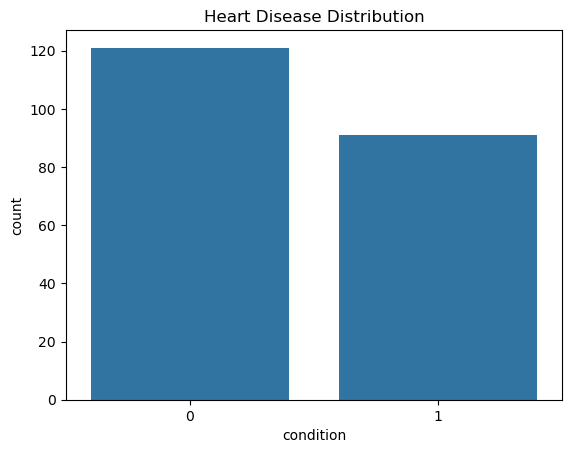

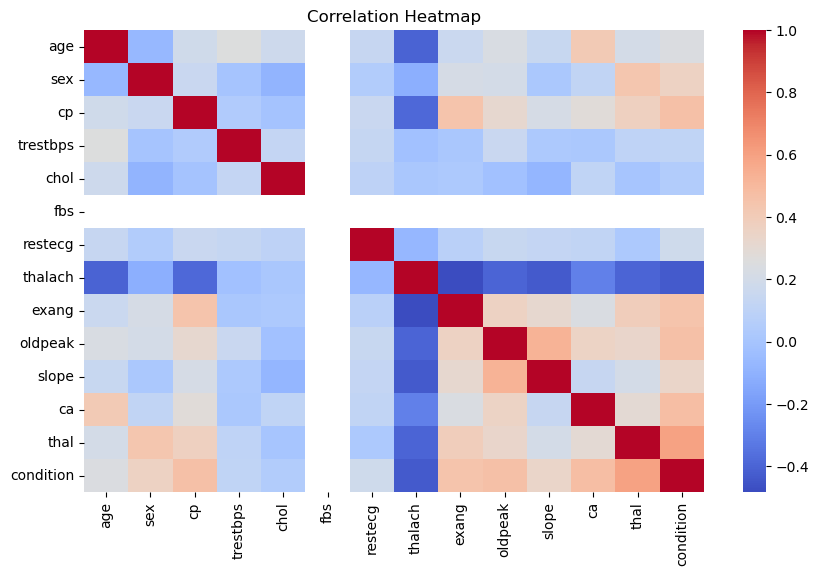

In [6]:
#  VISUALIZATION
sns.countplot(x='condition', data=df)
plt.title("Heart Disease Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# FEATURES & TARGET
X = df.drop('condition', axis=1)
y = df['condition']

In [11]:

#. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:

# . SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
#MODELS
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=200, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)


In [16]:

#  ACCURACY COMPARISON

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8372093023255814
Random Forest Accuracy: 0.8372093023255814


In [18]:

#. CLASSIFICATION REPORT

print("\nLogistic Regression Report:\n", classification_report(y_test, lr_pred))
print("\nRandom Forest Report:\n", classification_report(y_test, rf_pred))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84        22
           1       0.85      0.81      0.83        21

    accuracy                           0.84        43
   macro avg       0.84      0.84      0.84        43
weighted avg       0.84      0.84      0.84        43


Random Forest Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84        22
           1       0.85      0.81      0.83        21

    accuracy                           0.84        43
   macro avg       0.84      0.84      0.84        43
weighted avg       0.84      0.84      0.84        43



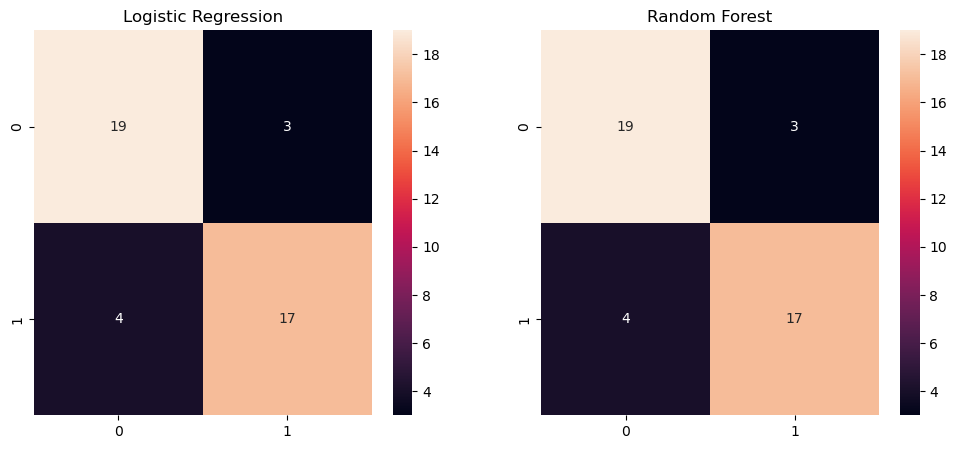

In [19]:

#  CONFUSION MATRIX

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("Random Forest")

plt.show()


In [20]:

# 13. CROSS VALIDATION

cv_lr = cross_val_score(lr, X_train, y_train, cv=5)
cv_rf = cross_val_score(rf, X_train, y_train, cv=5)

print("LR CV Accuracy:", cv_lr.mean())
print("RF CV Accuracy:", cv_rf.mean())

LR CV Accuracy: 0.8461675579322637
RF CV Accuracy: 0.8581105169340463


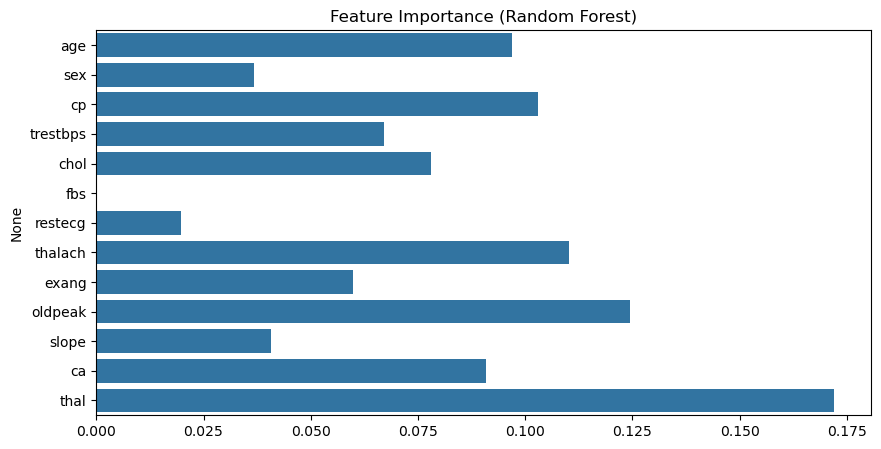

In [21]:

# 14. FEATURE IMPORTANCE (RF)

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()

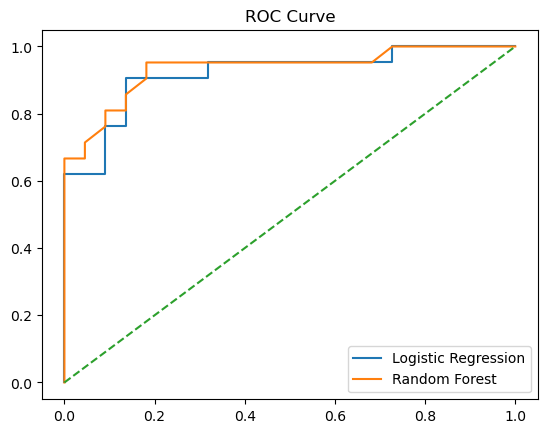

In [22]:

# 15. ROC CURVE (ADVANCED)

lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, lr_prob)
fpr2, tpr2, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr1, tpr1, label="Logistic Regression")
plt.plot(fpr2, tpr2, label="Random Forest")

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()